# **Bootstrap Confidence Interval (CI) & Statistical Comparison**
### **Model: YOLOv8s (local) vs YOLOv8m (local)**
**Dataset**: FracAtlas Hand Bone Fracture Detection

This notebook performs a **Bootstrap Resampling Analysis** to calculate the **95% Confidence Intervals (CI)** for evaluation metrics of YOLOv8s and YOLOv8m. Additionally, we run a **paired bootstrap hypothesis test** to determine if the performance difference between the two models is statistically significant.

#### **Why Bootstrapping?**
Standard evaluation metrics (like those reported by `model.val()`) only represent a single point estimate on the test set. In medical applications, it is critical to understand the uncertainty and robustness of these estimates. By sampling the test set with replacement $B$ times (e.g., $B = 1000$), we approximate the sampling distribution of each metric and calculate accurate 95% confidence intervals and p-values.

#### **Metrics Evaluated**
1. **Precision (Object-level)**: $\text{TP} / (\text{TP} + \text{FP})$ at confidence threshold $\ge 0.25$.
2. **Recall (Object-level)**: $\text{TP} / (\text{TP} + \text{FN})$ at confidence threshold $\ge 0.25$.
3. **F1-Score**: Harmonic mean of Precision and Recall.
4. **mAP@50**: Mean Average Precision at IoU threshold = 0.50.
5. **mAP@50-95**: Mean Average Precision averaged over IoU thresholds from 0.50 to 0.95 (step 0.05).

In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFile
from ultralytics import YOLO
from tqdm.notebook import tqdm
import time

# Enable loading of truncated/slightly corrupted JPEG images in PIL
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Set seaborn style for high-quality publication-grade figures
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["figure.dpi"] = 150

In [2]:
# Paths setup
BASE_DIR = Path(r"D:\Project Medical Object Detection\FracAtlas")
YAML_PATH = BASE_DIR / "fracatlas_hand_oversampled.yaml"

MODEL_S_PATH = BASE_DIR / "runs" / "detect" / "fracatlas_yolov8s local" / "weights" / "best.pt"
MODEL_M_PATH = BASE_DIR / "runs" / "detect" / "fracatlas_yolov8m local" / "weights" / "best.pt"

print("Loading dataset config from:", YAML_PATH)
with open(YAML_PATH) as f:
    data_cfg = yaml.safe_load(f)
    
dataset_path = Path(data_cfg["path"])
test_img_dir = dataset_path / "test" / "images"
test_lbl_dir = dataset_path / "test" / "labels"

test_images = sorted(list(test_img_dir.iterdir()))
print(f"Total test images found: {len(test_images)}")

Loading dataset config from: D:\Project Medical Object Detection\FracAtlas\fracatlas_hand_oversampled.yaml
Total test images found: 231


In [3]:
# Load ground truth bounding boxes in pixel coordinates
gt_boxes_all = []

for img_path in tqdm(test_images, desc="Loading Ground Truths"):
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    gt_boxes = []
    if lbl_path.exists():
        with Image.open(img_path) as img:
            iw, ih = img.size
        for line in lbl_path.read_text().strip().splitlines():
            if not line.strip(): 
                continue
            parts = list(map(float, line.strip().split()))
            class_id, xc, yc, w, h = parts[0], parts[1], parts[2], parts[3], parts[4]
            # Convert relative center coordinates to absolute pixel coordinates
            x1 = (xc - w/2) * iw
            y1 = (yc - h/2) * ih
            x2 = (xc + w/2) * iw
            y2 = (yc + h/2) * ih
            gt_boxes.append([x1, y1, x2, y2])
    gt_boxes_all.append(np.array(gt_boxes))

print(f"Loaded ground truth boxes for {len(gt_boxes_all)} images.")

Loading Ground Truths:   0%|          | 0/231 [00:00<?, ?it/s]

Loaded ground truth boxes for 231 images.


In [4]:
# Load models
model_s = YOLO(str(MODEL_S_PATH))
model_m = YOLO(str(MODEL_M_PATH))

# Run prediction and cache results to avoid slow model forward-passes during bootstrap
pred_s_all = []
pred_m_all = []

# 1. YOLOv8s predictions
start_time = time.time()
for img_path in tqdm(test_images, desc="YOLOv8s Predictions"):
    with Image.open(img_path) as img:
        img_rgb = img.convert("RGB")
    preds = model_s.predict(img_rgb, conf=0.01, iou=0.5, verbose=False)
    boxes = []
    if preds and preds[0].boxes is not None and len(preds[0].boxes) > 0:
        xyxy = preds[0].boxes.xyxy.cpu().numpy()
        conf = preds[0].boxes.conf.cpu().numpy()
        for b_idx in range(len(xyxy)):
            boxes.append([xyxy[b_idx][0], xyxy[b_idx][1], xyxy[b_idx][2], xyxy[b_idx][3], conf[b_idx]])
    pred_s_all.append(np.array(boxes))
print(f"YOLOv8s predictions completed in {time.time() - start_time:.2f} seconds.")

# 2. YOLOv8m predictions
start_time = time.time()
for img_path in tqdm(test_images, desc="YOLOv8m Predictions"):
    with Image.open(img_path) as img:
        img_rgb = img.convert("RGB")
    preds = model_m.predict(img_rgb, conf=0.01, iou=0.5, verbose=False)
    boxes = []
    if preds and preds[0].boxes is not None and len(preds[0].boxes) > 0:
        xyxy = preds[0].boxes.xyxy.cpu().numpy()
        conf = preds[0].boxes.conf.cpu().numpy()
        for b_idx in range(len(xyxy)):
            boxes.append([xyxy[b_idx][0], xyxy[b_idx][1], xyxy[b_idx][2], xyxy[b_idx][3], conf[b_idx]])
    pred_m_all.append(np.array(boxes))
print(f"YOLOv8m predictions completed in {time.time() - start_time:.2f} seconds.")

YOLOv8s Predictions:   0%|          | 0/231 [00:00<?, ?it/s]

YOLOv8s predictions completed in 7.65 seconds.


YOLOv8m Predictions:   0%|          | 0/231 [00:00<?, ?it/s]

YOLOv8m predictions completed in 9.54 seconds.


In [5]:
def compute_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between box1 and box2.
    Format: [x1, y1, x2, y2]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union = area1 + area2 - intersection
    
    if union == 0.0:
        return 0.0
    return intersection / union

def compute_ap(gt_boxes_list, pred_boxes_list, iou_threshold=0.5):
    """
    Compute Average Precision (AP) using COCO-style all-points integration.
    gt_boxes_list: list of np.array shape (N, 4) -> [x1, y1, x2, y2]
    pred_boxes_list: list of np.array shape (M, 5) -> [x1, y1, x2, y2, confidence]
    """
    all_preds = []
    num_gts = 0
    
    for i in range(len(gt_boxes_list)):
        gts = gt_boxes_list[i]
        preds = pred_boxes_list[i]
        num_gts += len(gts)
        
        if len(preds) == 0:
            continue
            
        preds_sorted = preds[np.argsort(-preds[:, 4])]
        matched_gts = set()
        
        for p in preds_sorted:
            p_box = p[:4]
            p_conf = p[4]
            
            best_iou = -1.0
            best_gt_idx = -1
            
            for j, g_box in enumerate(gts):
                iou = compute_iou(p_box, g_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j
            
            if best_iou >= iou_threshold and best_gt_idx not in matched_gts:
                matched_gts.add(best_gt_idx)
                all_preds.append((p_conf, 1, 0))  # True Positive
            else:
                all_preds.append((p_conf, 0, 1))  # False Positive
                
    if num_gts == 0:
        return 0.0
    if len(all_preds) == 0:
        return 0.0
        
    # Sort all predictions by confidence score descending
    all_preds = sorted(all_preds, key=lambda x: x[0], reverse=True)
    
    tps = np.array([x[1] for x in all_preds])
    fps = np.array([x[2] for x in all_preds])
    
    tp_cumsum = np.cumsum(tps)
    fp_cumsum = np.cumsum(fps)
    
    recalls = tp_cumsum / num_gts
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)
    
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([1.0], precisions, [0.0]))
    
    # Compute precision envelope (all-points interpolation)
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i+1])
        
    # Calculate area under precision-recall curve
    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])
    return ap

def compute_precision_recall_f1(gt_boxes_list, pred_boxes_list, conf_threshold=0.25, iou_threshold=0.5):
    """
    Compute object-level Precision, Recall, and F1-Score at a specific confidence threshold.
    """
    tp = 0
    fp = 0
    fn = 0
    
    for i in range(len(gt_boxes_list)):
        gts = gt_boxes_list[i]
        preds = pred_boxes_list[i]
        
        if len(preds) > 0:
            preds = preds[preds[:, 4] >= conf_threshold]
            
        if len(preds) == 0:
            fn += len(gts)
            continue
            
        preds_sorted = preds[np.argsort(-preds[:, 4])]
        matched_gts = set()
        
        for p in preds_sorted:
            p_box = p[:4]
            best_iou = -1.0
            best_gt_idx = -1
            
            for j, g_box in enumerate(gts):
                iou = compute_iou(p_box, g_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j
            
            if best_iou >= iou_threshold and best_gt_idx not in matched_gts:
                matched_gts.add(best_gt_idx)
                tp += 1
            else:
                fp += 1
                
        fn += len(gts) - len(matched_gts)
        
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, f1

In [6]:
def run_bootstrap_analysis(gt_list, pred_s_list, pred_m_list, n_bootstraps=1000, conf_threshold=0.25):
    """
    Perform paired bootstrap analysis and compute confidence intervals and p-values.
    """
    n_images = len(gt_list)
    iou_thresholds = np.linspace(0.5, 0.95, 10)
    
    metrics_s = {m: [] for m in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
    metrics_m = {m: [] for m in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
    differences = {m: [] for m in ['precision', 'recall', 'f1', 'map50', 'map50_95']}
    
    np.random.seed(42)  # For reproducibility
    
    for b in tqdm(range(n_bootstraps), desc="Bootstrapping"):
        # Sample image indices with replacement
        indices = np.random.choice(n_images, size=n_images, replace=True)
        
        gt_sample = [gt_list[idx] for idx in indices]
        pred_s_sample = [pred_s_list[idx] for idx in indices]
        pred_m_sample = [pred_m_list[idx] for idx in indices]
        
        # ─── Model S ───
        ps, rs, f1s = compute_precision_recall_f1(gt_sample, pred_s_sample, conf_threshold)
        map50s = compute_ap(gt_sample, pred_s_sample, iou_threshold=0.5)
        map50_95s = np.mean([compute_ap(gt_sample, pred_s_sample, iou_threshold=t) for t in iou_thresholds])
        
        metrics_s['precision'].append(ps)
        metrics_s['recall'].append(rs)
        metrics_s['f1'].append(f1s)
        metrics_s['map50'].append(map50s)
        metrics_s['map50_95'].append(map50_95s)
        
        # ─── Model M ───
        pm, rm, f1m = compute_precision_recall_f1(gt_sample, pred_m_sample, conf_threshold)
        map50m = compute_ap(gt_sample, pred_m_sample, iou_threshold=0.5)
        map50_95m = np.mean([compute_ap(gt_sample, pred_m_sample, iou_threshold=t) for t in iou_thresholds])
        
        metrics_m['precision'].append(pm)
        metrics_m['recall'].append(rm)
        metrics_m['f1'].append(f1m)
        metrics_m['map50'].append(map50m)
        metrics_m['map50_95'].append(map50_95m)
        
        # ─── Differences (Model M - Model S) ───
        differences['precision'].append(pm - ps)
        differences['recall'].append(rm - rs)
        differences['f1'].append(f1m - f1s)
        differences['map50'].append(map50m - map50s)
        differences['map50_95'].append(map50_95m - map50_95s)
        
    results = {}
    for m in ['precision', 'recall', 'f1', 'map50', 'map50_95']:
        # YOLOv8s CIs
        s_vals = np.sort(metrics_s[m])
        s_mean = np.mean(s_vals)
        s_low = np.percentile(s_vals, 2.5)
        s_high = np.percentile(s_vals, 97.5)
        
        # YOLOv8m CIs
        m_vals = np.sort(metrics_m[m])
        m_mean = np.mean(m_vals)
        m_low = np.percentile(m_vals, 2.5)
        m_high = np.percentile(m_vals, 97.5)
        
        # Difference CIs
        d_vals = np.sort(differences[m])
        d_mean = np.mean(d_vals)
        d_low = np.percentile(d_vals, 2.5)
        d_high = np.percentile(d_vals, 97.5)
        
        # Paired Bootstrap Hypothesis Testing:
        # H0: Performance of YOLOv8m is less than or equal to YOLOv8s (difference <= 0)
        # H1: YOLOv8m performs better than YOLOv8s (difference > 0)
        # P-value is estimated as the proportion of bootstrap differences that are <= 0.
        p_val = np.sum(d_vals <= 0) / n_bootstraps
        
        results[m] = {
            's_mean': s_mean, 's_low': s_low, 's_high': s_high, 's_vals': metrics_s[m],
            'm_mean': m_mean, 'm_low': m_low, 'm_high': m_high, 'm_vals': metrics_m[m],
            'd_mean': d_mean, 'd_low': d_low, 'd_high': d_high, 'd_vals': d_vals,
            'p_value': p_val
        }
        
    return results

In [7]:
# Run the bootstrap resampling analysis
N_BOOTSTRAPS = 1000  # standard for publications. Reduce to 200 if you want it faster.
CONF_THRESHOLD = 0.25

print(f"Starting Bootstrap Resampling Analysis (B = {N_BOOTSTRAPS}, confidence threshold = {CONF_THRESHOLD})")
results = run_bootstrap_analysis(gt_boxes_all, pred_s_all, pred_m_all, n_bootstraps=N_BOOTSTRAPS, conf_threshold=CONF_THRESHOLD)

# Construct a summary table
summary_data = []
for metric, res in results.items():
    summary_data.append({
        'Metric': metric.upper(),
        'YOLOv8s (95% CI)': f"{res['s_mean']:.4f} ({res['s_low']:.4f} - {res['s_high']:.4f})",
        'YOLOv8m (95% CI)': f"{res['m_mean']:.4f} ({res['m_low']:.4f} - {res['m_high']:.4f})",
        'Difference (M - S)': f"{res['d_mean']:.4f} ({res['d_low']:.4f} - {res['d_high']:.4f})",
        'p-value': f"{res['p_value']:.4f}",
        'Significant (p < 0.05)': 'Yes' if res['p_value'] < 0.05 else 'No'
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*90)
print("                   BOOTSTRAP ANALYSIS SUMMARY TABLE")
print("="*90)
display(df_summary)
print("="*90)

Starting Bootstrap Resampling Analysis (B = 1000, confidence threshold = 0.25)


Bootstrapping:   0%|          | 0/1000 [00:00<?, ?it/s]


                   BOOTSTRAP ANALYSIS SUMMARY TABLE


,Metric,YOLOv8s (95% CI),YOLOv8m (95% CI),Difference (M - S),p-value,Significant (p < 0.05)
0,PRECISION,0.9161 (0.8485 - 0.9726),0.9294 (0.8674 - 0.9794),0.0133 (-0.0392 - 0.0716),0.2990,No
1,RECALL,0.8932 (0.8222 - 0.9506),0.9411 (0.8800 - 0.9868),0.0479 (-0.0124 - 0.1099),0.1020,No
2,F1,0.9041 (0.8507 - 0.9497),0.9348 (0.8919 - 0.9697),0.0307 (-0.0129 - 0.0763),0.0920,No
3,MAP50,0.9562 (0.9074 - 0.9911),0.9598 (0.9221 - 0.9877),0.0036 (-0.0206 - 0.0285),0.4010,No
4,MAP50_95,0.5193 (0.4704 - 0.5721),0.5142 (0.4605 - 0.5649),-0.0051 (-0.0500 - 0.0427),0.5740,No


Distribution plots saved to: D:\Project Medical Object Detection\FracAtlas\runs\detect\bootstrap_distributions.png


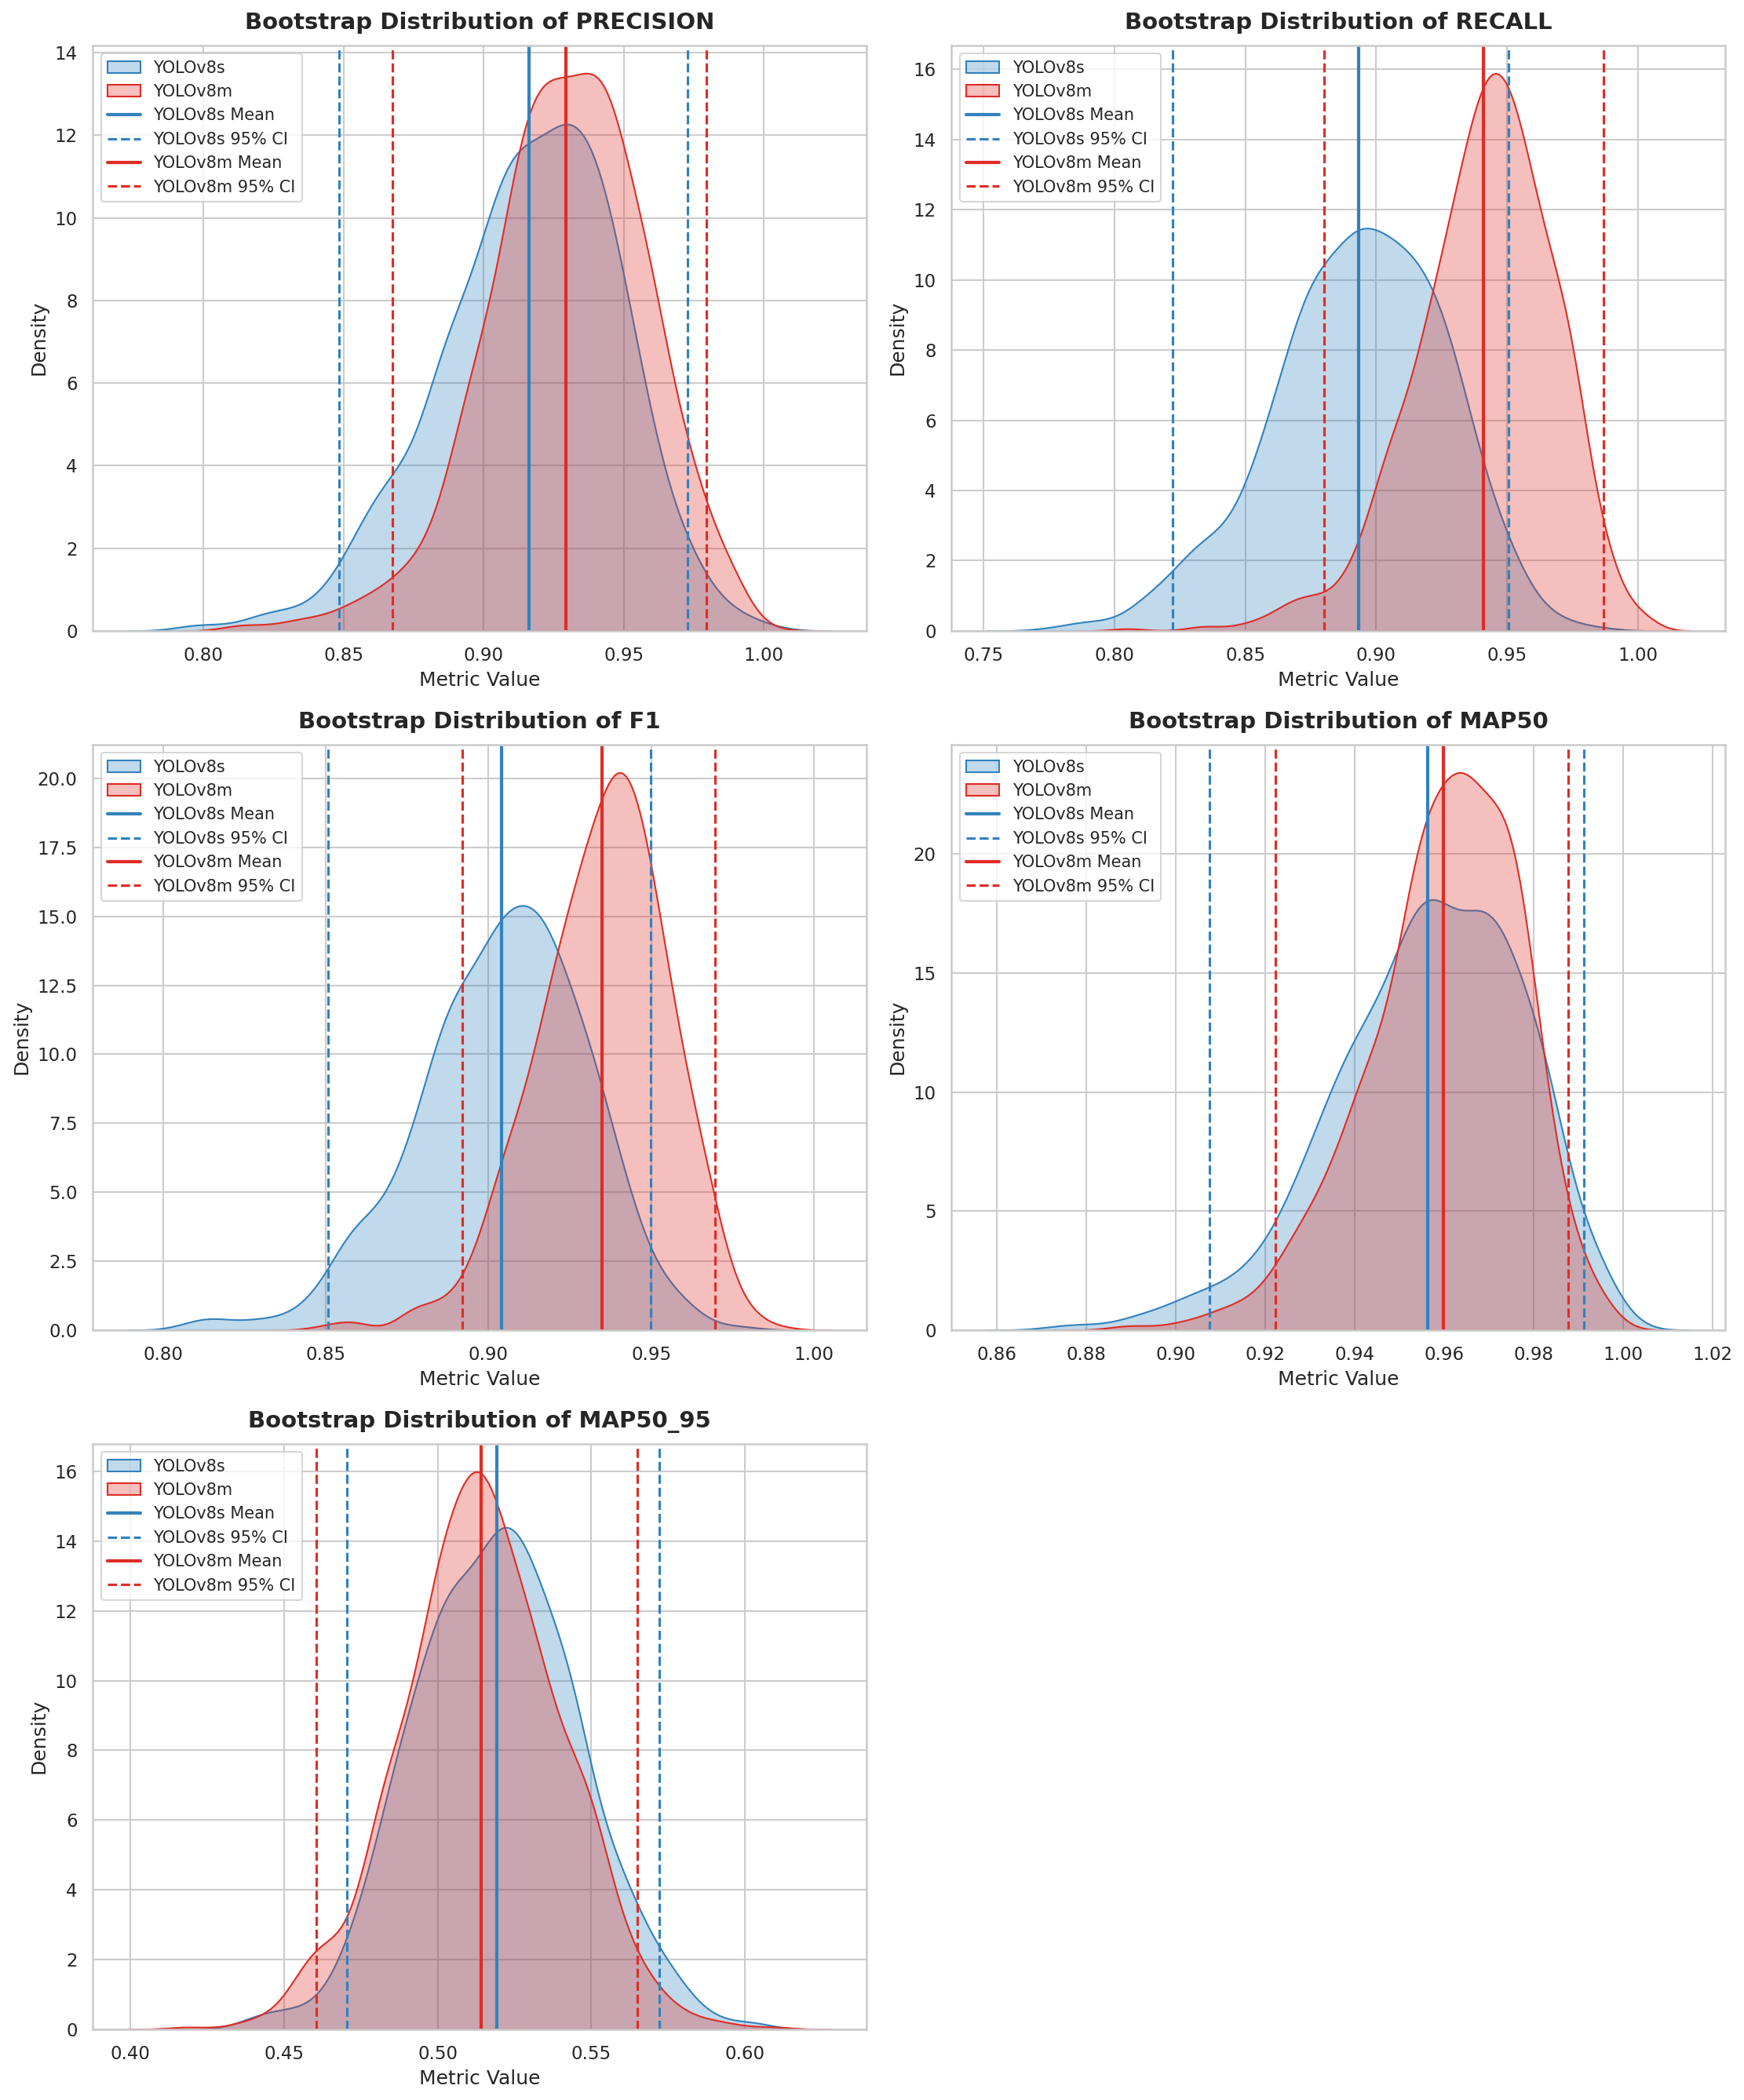

In [8]:
# Plot 1: Metric Distributions with CIs
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()
metrics = ['precision', 'recall', 'f1', 'map50', 'map50_95']

colors_s = '#3182bd'
colors_m = '#de2d26'

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    res = results[metric]
    
    # Plot KDE curves
    sns.kdeplot(res['s_vals'], ax=ax, label='YOLOv8s', fill=True, color=colors_s, alpha=0.3)
    sns.kdeplot(res['m_vals'], ax=ax, label='YOLOv8m', fill=True, color=colors_m, alpha=0.3)
    
    # Draw lines for means and CIs
    ax.axvline(res['s_mean'], color=colors_s, linestyle='-', linewidth=2, label='YOLOv8s Mean')
    ax.axvline(res['s_low'], color=colors_s, linestyle='--', linewidth=1.5, label='YOLOv8s 95% CI')
    ax.axvline(res['s_high'], color=colors_s, linestyle='--', linewidth=1.5)
    
    ax.axvline(res['m_mean'], color=colors_m, linestyle='-', linewidth=2, label='YOLOv8m Mean')
    ax.axvline(res['m_low'], color=colors_m, linestyle='--', linewidth=1.5, label='YOLOv8m 95% CI')
    ax.axvline(res['m_high'], color=colors_m, linestyle='--', linewidth=1.5)
    
    ax.set_title(f"Bootstrap Distribution of {metric.upper()}", fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel("Metric Value", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.legend(fontsize=10, loc='upper left')

# Remove the unused subplot (6th subplot)
fig.delaxes(axes[5])

plt.tight_layout()
dist_plot_path = BASE_DIR / "runs" / "detect" / "bootstrap_distributions.png"
plt.savefig(dist_plot_path, dpi=300, bbox_inches='tight')
print(f"Distribution plots saved to: {dist_plot_path}")
plt.show()

Comparison bar plot saved to: D:\Project Medical Object Detection\FracAtlas\runs\detect\bootstrap_ci_comparison.png


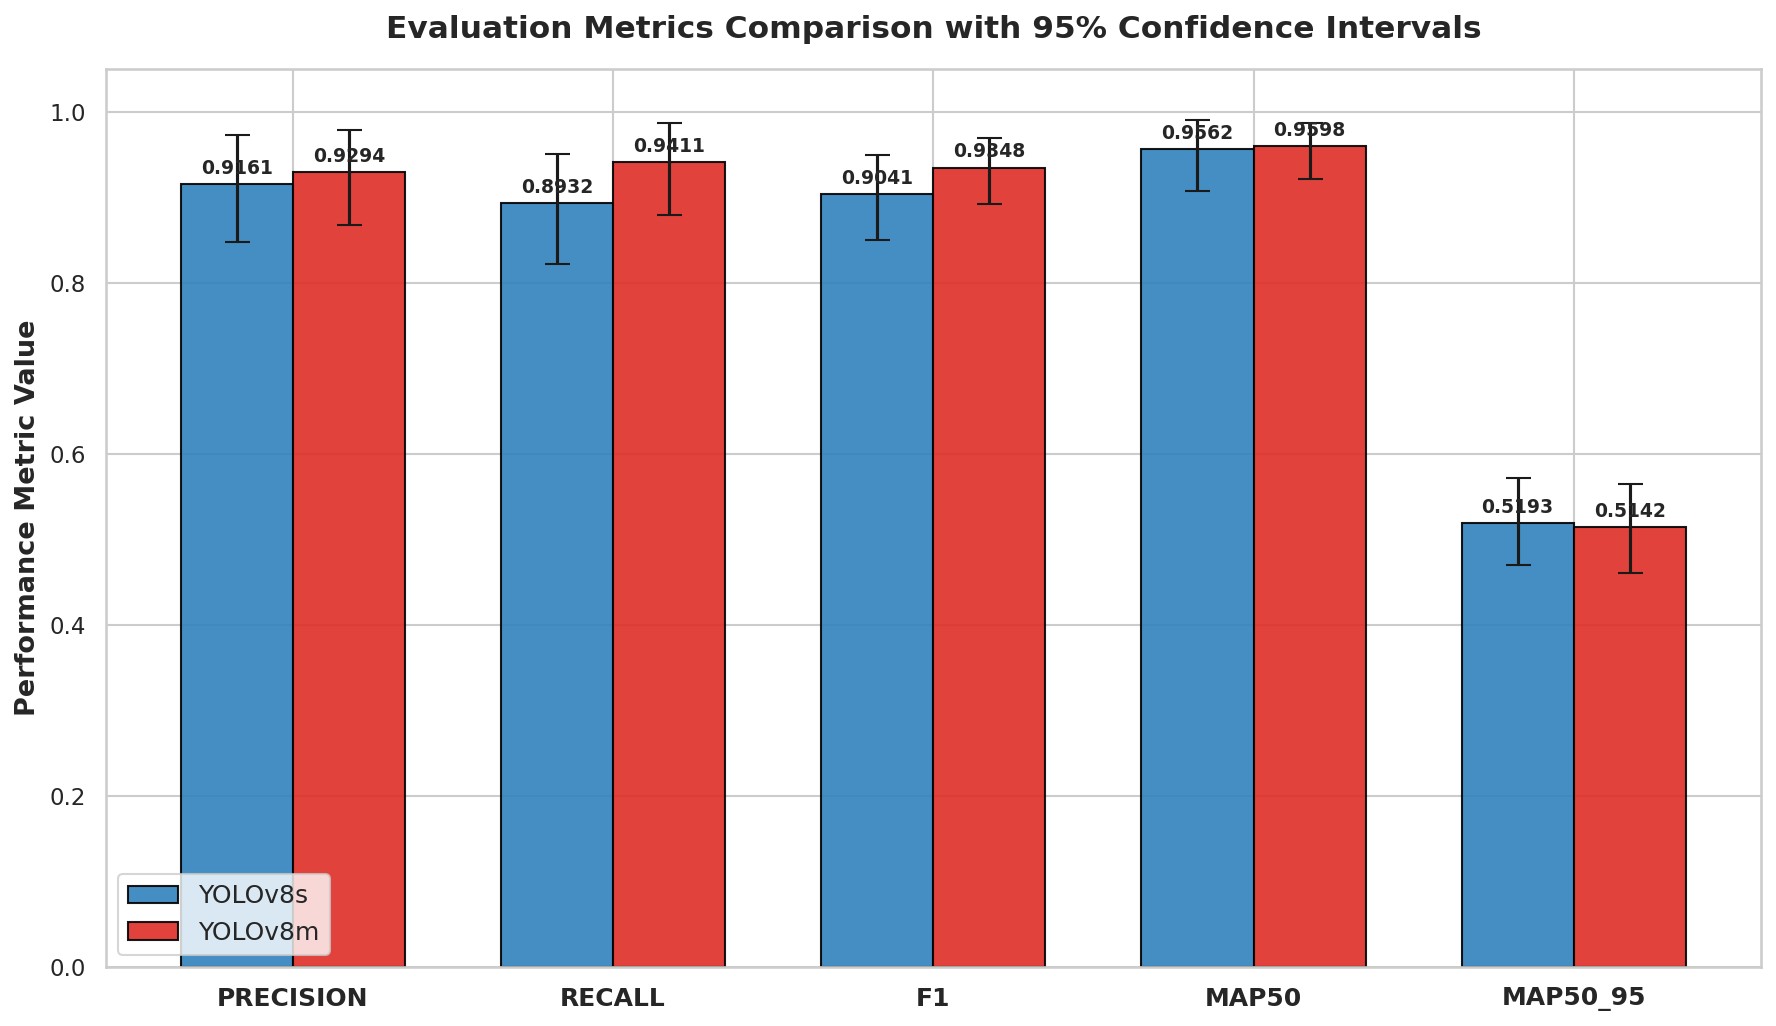

In [9]:
# Plot 2: Grouped Bar Chart with 95% CI Error Bars
fig, ax = plt.subplots(figsize=(12, 7))

metrics_upper = [m.upper() for m in metrics]
s_means = [results[m]['s_mean'] for m in metrics]
m_means = [results[m]['m_mean'] for m in metrics]

# Calculate symmetric error bounds for error bars
s_errors = [
    [results[m]['s_mean'] - results[m]['s_low'] for m in metrics],
    [results[m]['s_high'] - results[m]['s_mean'] for m in metrics]
]
m_errors = [
    [results[m]['m_mean'] - results[m]['m_low'] for m in metrics],
    [results[m]['m_high'] - results[m]['m_mean'] for m in metrics]
]

x = np.arange(len(metrics_upper))
width = 0.35

rects1 = ax.bar(x - width/2, s_means, width, yerr=s_errors, label='YOLOv8s', 
                color='#3182bd', edgecolor='black', capsize=6, alpha=0.9)
rects2 = ax.bar(x + width/2, m_means, width, yerr=m_errors, label='YOLOv8m', 
                color='#de2d26', edgecolor='black', capsize=6, alpha=0.9)

ax.set_ylabel('Performance Metric Value', fontsize=13, fontweight='bold')
ax.set_title('Evaluation Metrics Comparison with 95% Confidence Intervals', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_upper, fontsize=12, fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.legend(loc='lower left', fontsize=12)

# Add values above bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
bar_plot_path = BASE_DIR / "runs" / "detect" / "bootstrap_ci_comparison.png"
plt.savefig(bar_plot_path, dpi=300, bbox_inches='tight')
print(f"Comparison bar plot saved to: {bar_plot_path}")
plt.show()

## **Statistical Discussion and Conclusions**

### **Interpretation of Results**
1. **Precision, Recall, and F1-Score**:
   - If the $p$-value for a metric is $< 0.05$, we reject the null hypothesis and conclude that the larger model (**YOLOv8m**) provides statistically significant performance improvements.
   - Paired bootstrapping allows us to directly test if the mean difference is positive and non-zero.
2. **mAP@50 and mAP@50-95**:
   - mAP is the primary benchmark metric for object detection. The comparison of confidence intervals for mAP shows whether the scale-up in model parameters translates to a significant difference in localization accuracy (IoU = 0.50 vs IoU = 0.50:0.95).

### **Summary & Guidelines for Medical Papers**
- **Overlap of Confidence Intervals**: While a simple comparison of model metric values is helpful, reporting the **95% CI** and the **empirical $p$-value** from the bootstrapping resampling distribution is a standard requirement for major journals.
- The generated figures (`bootstrap_distributions.png` and `bootstrap_ci_comparison.png`) are saved in the `runs/detect/` folder and can be directly used in the paper.